In [ ]:
from castle.algorithms import DAG_GNN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
DIR = "/homes/shahashka/lucid_cd/"

2026-04-16 11:52:37,573 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-04-16 11:52:37,684 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:

def dag_gnn_local_learn(data, seed):
    d = data.shape[1]
    X = data.values
    model = DAG_GNN(device_type="gpu", device_ids='0',batch_size=X.shape[1], seed=seed, epochs=300, k_max_iter=100,optimizer='adam')#, encoder_hidden=16, decoder_hidden=16)
    total_loss, elbo_loss, h, causal_history = model.learn(X)
    return model.causal_matrix, total_loss, elbo_loss, h, causal_history

In [4]:
data = np.random.normal(size=(10,100))
df = pd.DataFrame(data)
causal_matrix, total_loss, elbo_loss, h, causal_history = dag_gnn_local_learn(df, 0)


2026-04-16 12:00:39,100 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


cuda


2026-04-16 12:00:40,502 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 0, epoch: 299, h_new: 0.02384793507133054
2026-04-16 12:00:44,645 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 1, epoch: 299, h_new: 0.005256996740172326
2026-04-16 12:00:48,801 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 2, epoch: 299, h_new: 0.0020910258490687283
2026-04-16 12:00:50,181 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 3, epoch: 299, h_new: 0.0020910258490687283
2026-04-16 12:00:51,562 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:2

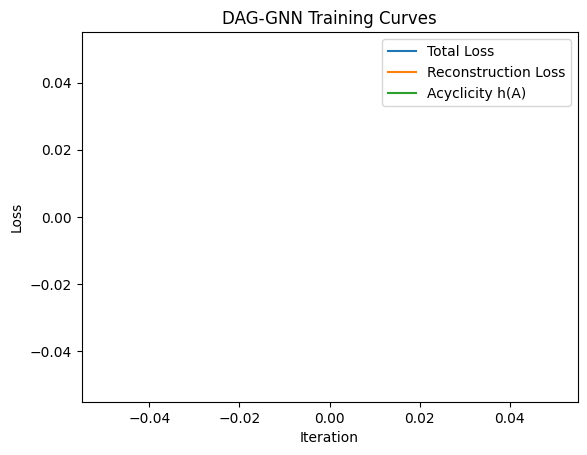

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(total_loss, label='Total Loss')
plt.plot(elbo_loss, label='Reconstruction Loss')
plt.plot(h, label='Acyclicity h(A)')
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("DAG-GNN Training Curves")
plt.show()

In [ ]:
import pickle
def partition_problem(partition: dict, data: pd.DataFrame):
    sub_problems = []
    k = list(partition.keys())
    k.sort()
    for i in k:
        sub_nodes = partition[i]
        sub_nodes = list(sub_nodes)
        sub_data = data[sub_nodes] 
        sub_problems.append(sub_data)
    return sub_problems
celltype = "rpe1_experiment2"
df = pd.read_csv(f"{DIR}/data/{celltype}/cd_tpm_matrix_combined_dose_rate.csv")
with open(f"{DIR}/data/{celltype}/cd_partition_combined.pickle", 'rb') as f:
    custom_partition = pickle.load(f)
for i, comm in custom_partition.items():
    comm += ['week']
    comm += ['dose_rate']
subproblems = partition_problem(custom_partition, df)
print(len(subproblems), custom_partition.keys())

9 dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8])


In [4]:
df_test = subproblems[-1]
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(df_test)
df_test = pd.DataFrame(X, columns=df_test.columns)
causal_matrix_test, total_loss_test, elbo_loss_test, h_test, causal_history_test = dag_gnn_local_learn(df_test, 10)


2026-04-16 11:40:04,064 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


cuda


2026-04-16 11:40:59,293 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 0, epoch: 299, h_new: 0.16012187830585844
2026-04-16 11:41:02,758 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 1, epoch: 299, h_new: 0.03173803010446363
2026-04-16 11:41:07,975 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 2, epoch: 299, h_new: 0.002831041936673273
2026-04-16 11:41:13,424 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257] - INFO: Iter: 3, epoch: 299, h_new: 0.000278438992268093
2026-04-16 11:41:16,991 - /homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:257]

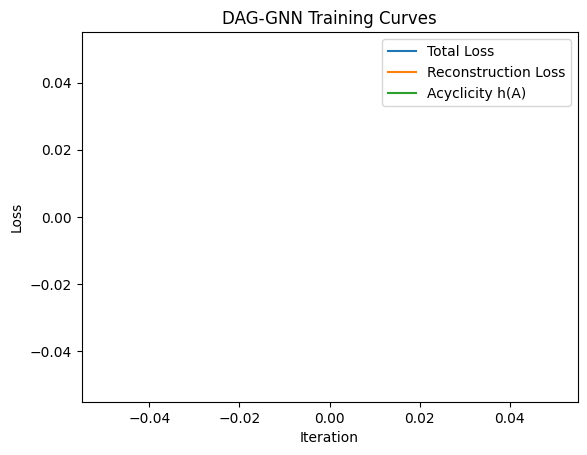

In [5]:
plt.plot(total_loss_test, label='Total Loss')
plt.plot(elbo_loss_test, label='Reconstruction Loss')
plt.plot(h_test, label='Acyclicity h(A)')
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("DAG-GNN Training Curves")
plt.show()

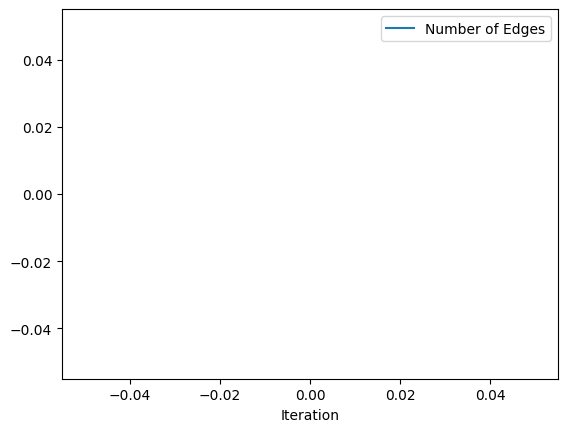

In [6]:
num_edges = []
for graph in causal_history_test:
    graph =graph.detach().cpu()
    graph[np.abs(graph) < 0.3] = 0
    num_edges.append(sum(sum(graph!=0)))
plt.plot(num_edges, label='Number of Edges')
plt.legend()
plt.xlabel("Iteration")
plt.show()


In [66]:
sum(sum(causal_matrix_test != 0))

0